In [1]:
import pandas as pd
from itertools import combinations
import numpy as np

In [2]:
#Loading in the roads data file
df1 = pd.read_csv('./data/_roads3.csv')

# print(df1.head())

#Filtering on only the N1 road
roads = ['N1', 'N2'] + [f'N{i}' for i in range(100, 300)]

dfN = df1[df1['road'].isin(roads)]
# dfN['road'].value_counts()


In [3]:
#Creating the source and sink for the new data frame, based on the minimal and maximal chainage


source_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmin()]
sink_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmax()]

df_proc = (
    pd.concat([source_rows, sink_rows])
    .drop_duplicates(subset=['road', 'chainage', 'lrp'])
    .sort_values(['road', 'chainage'])
    .reset_index(drop=True)
)

df_proc


,road,chainage,lrp,lat,lon,gap,type,name
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit..."
2,N101,0.000,LRPS,23.454139,91.212861,NaN,Others,Start of Road from N120 at Balutopa
3,N101,6.021,LRPE,23.459306,91.253389,NaN,Others,End of road Bibir bazar Bridge
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail
6,N103,0.000,LRPS,23.957028,91.115528,NaN,Others,Road start from N102 at Kuatali.
7,N103,4.779,LRPE,23.996889,91.109278,NaN,Others,Intersection with N102 at Ghaturia.
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031
9,N104,49.630,LRPE,22.825749,91.101444,NaN,Others,Meet with Z1441& Z1405 at Sonapur.


In [4]:
df_proc['total_length'] = df_proc.groupby('road')['chainage'].transform('max')

df_filtered = (df_proc[df_proc['total_length'] > 25]).copy()
# df_filtered.drop('total_length', axis=1, inplace=True))
display(df_filtered.head())
df_filtered.road.value_counts()

,road,chainage,lrp,lat,lon,gap,type,name,total_length
0,N1,0.000,LRPS,23.706028,90.443333,NaN,Others,Start of Road after Jatrabari Flyover infront...,462.254
1,N1,462.254,LRPE,20.862917,92.298083,NaN,Others,"End of Road at Shapla Chattar ,Teknaf Meet wit...",462.254
4,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,82.682
5,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail,82.682
8,N104,0.000,LRPS,23.009667,91.399416,NaN,Others,Intersection with Z1031,49.630


road
N1      2
N102    2
N104    2
N105    2
N106    2
N2      2
N204    2
N207    2
N208    2
Name: count, dtype: int64

In [5]:
df_filtered['model_type'] = 'sourcesink'
df_filtered['length'] = 0
df_filtered['condition'] = None

df_filtered = df_filtered[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_filtered.rename(columns={'lrp': 'id'}, inplace=True)

df_filtered

,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000
1,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254
4,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000
5,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000
9,N104,LRPE,sourcesink,Meet with Z1441& Z1405 at Sonapur.,22.825749,91.101444,0,None,49.630
10,N105,LRPS,sourcesink,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,None,0.000
11,N105,LRP048,sourcesink,"B.Bridge 83 km,Tangail 60 km / End of Road In...",23.989527,90.358222,0,None,48.870
12,N106,LRPS,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0,None,0.000
13,N106,LRPE,sourcesink,The road ends Infront of DC Bunglow,22.648527,92.201833,0,None,66.850


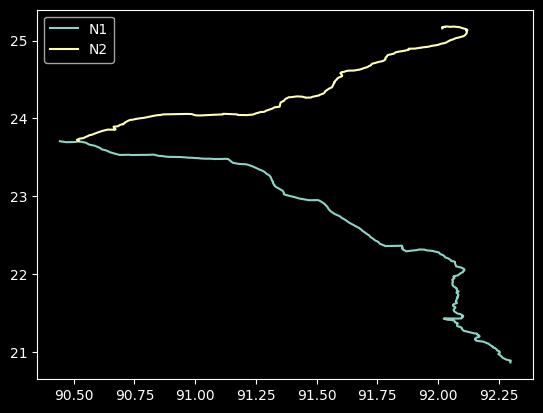

In [6]:
# Visual inspection of N1 and N2
import matplotlib.pyplot as plt

df_plot = dfN[dfN['road'].isin(['N1', 'N2'])]

for road, data in df_plot.groupby('road'):
    plt.plot(data['lon'], data['lat'], label=road)

plt.legend()
plt.show()

In [7]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

In [8]:
df_n1 = dfN[dfN['road'] == 'N1'].copy()
df_n2 = dfN[dfN['road'] == 'N2'].copy()

df_cross = df_n1.merge(df_n2, how='cross', suffixes=('_n1', '_n2'))

df_cross['distance'] = haversine(
    df_cross['lat_n1'],
    df_cross['lon_n1'],
    df_cross['lat_n2'],
    df_cross['lon_n2']
)

intersections = df_cross[df_cross['distance'] < 0.05]

intersections[['road_n1','chainage_n1','lrp_n1',
               'road_n2','chainage_n2','lrp_n2',
               'distance']]



,road_n1,chainage_n1,lrp_n1,road_n2,chainage_n2,lrp_n2,distance
15062,N1,8.763,LRP009a,N2,0.0,LRPS,0.020374


In [9]:
roads = df_filtered['road'].unique()
road_pairs = list(combinations(roads, 2))


In [10]:
all_intersections = []

for r1, r2 in road_pairs:

    df_r1 = dfN[dfN['road'] == r1]
    df_r2 = dfN[dfN['road'] == r2]

    df_cross = df_r1.merge(df_r2, how='cross', suffixes=('_1', '_2'))

    df_cross['distance'] = haversine(
        df_cross['lat_1'],
        df_cross['lon_1'],
        df_cross['lat_2'],
        df_cross['lon_2']
    )

    inter = df_cross[df_cross['distance'] < 0.05]

    all_intersections.append(inter)

intersections = pd.concat(all_intersections, ignore_index=True)
intersections[['road_1','chainage_1','lrp_1',
               'road_2','chainage_2','lrp_2',
               'distance']]

display(intersections)


,road_1,chainage_1,lrp_1,lat_1,lon_1,gap_1,type_1,name_1,road_2,chainage_2,lrp_2,lat_2,lon_2,gap_2,type_2,name_2,distance
0,N1,81.801,LRP083a,23.478944,91.117722,NaN,Culvert,Box culvert,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,0.048258
1,N1,81.829,LRP084,23.478972,91.117999,NaN,KmPost,Km post missing,N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,0.019837
2,N1,81.846,LRP084a,23.478972,91.118166,NaN,"SideRoad,Left",Road to Brahmanbaria(N102),N102,0.000,LRPS,23.478972,91.118194,NaN,Others,Start of road from N1 Mainamati,0.002835
3,N1,145.409,LRP148a,23.009556,91.381360,NaN,CrossRoad / KmPost,Intersection with N104 / Km post missing,N104,1.878,LRP001a,23.009528,91.381444,NaN,CrossRoad,Right to Comilla Left to Chittagong,0.009078
4,N1,11.936,LRP012c,23.690416,90.546583,NaN,"SideRoad,Right",Right to Syedpur (R113) left to Joydebpur N105),N105,0.000,LRPS,23.690416,90.546611,NaN,Others,"Starts of road from N1,Dhaka teknaf road at Ma...",0.002831
5,N1,8.763,LRP009a,23.706083,90.521527,NaN,"SideRoad,Left",Road to Sylhet (N2),N2,0.000,LRPS,23.705917,90.521444,NaN,Others,Road Start from N1 at Katchpur,0.020374
6,N102,82.682,LRPE,24.050611,91.114667,NaN,Others,Meet with N 2 at Sanail,N2,85.823,LRP086a,24.050833,91.114444,NaN,"SideRoad,Right",Road to Mainamoti(N102),0.033466
7,N105,12.803,LRP012a,23.785194,90.568805,NaN,CrossRoad,N2 Dhaka-Sylhet -Jaflong Road,N2,11.464,LRP012a,23.785333,90.568555,NaN,CrossRoad,Intersection with N105,0.029759
8,N105,12.803,LRP012a,23.785194,90.568805,NaN,CrossRoad,N2 Dhaka-Sylhet -Jaflong Road,N2,11.476,LRP012b,23.785389,90.568888,BS,Bridge,Bridge start,0.023229
9,N105,12.803,LRP012a,23.785194,90.568805,NaN,CrossRoad,N2 Dhaka-Sylhet -Jaflong Road,N2,11.517,LRP012c,23.785389,90.569110,BE,Bridge,Bridge end,0.037868


In [11]:
# Maak groepen van punten die bij dezelfde intersection horen
intersection_groups = {}
group_id = 0

for _, row in intersections.iterrows():

    a = (row['road_1'], row['lrp_1'])
    b = (row['road_2'], row['lrp_2'])

    if a in intersection_groups:
        intersection_groups[b] = intersection_groups[a]

    elif b in intersection_groups:
        intersection_groups[a] = intersection_groups[b]

    else:
        intersection_groups[a] = group_id
        intersection_groups[b] = group_id
        group_id += 1

In [12]:
df_i1 = intersections[['road_1','lrp_1','chainage_1']].rename(columns={
    'road_1':'road',
    'lrp_1':'lrp',
    'chainage_1':'chainage'
})

df_i2 = intersections[['road_2','lrp_2','chainage_2']].rename(columns={
    'road_2':'road',
    'lrp_2':'lrp',
    'chainage_2':'chainage'
})

df_intersections = pd.concat([df_i1, df_i2]) #.drop_duplicates()

df_intersections = df_intersections.merge(
    dfN,
    on=['road','lrp','chainage'],
    how='left'
)
# print(df_intersections.head())

df_intersections['model_type'] = 'intersection'
df_intersections['length'] = 0
df_intersections['condition'] = None
# Koppel intersection groep aan dataframe
df_intersections['intersection_group'] = df_intersections.apply(
    lambda r: intersection_groups.get((r['road'], r['lrp']), None),
    axis=1
)

df_intersections = df_intersections[['road','lrp','model_type','name','lat','lon','length','condition','chainage', 'intersection_group']]

df_intersections = df_intersections.rename(columns={'lrp':'id'})

display(df_intersections)





,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801,0
1,N1,LRP084,intersection,Km post missing,23.478972,91.117999,0,None,81.829,0
2,N1,LRP084a,intersection,Road to Brahmanbaria(N102),23.478972,91.118166,0,None,81.846,0
3,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409,1
4,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936,2
5,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763,3
6,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,4
7,N105,LRP012a,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,0,None,12.803,5
8,N105,LRP012a,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,0,None,12.803,5
9,N105,LRP012a,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,0,None,12.803,5


In [13]:
def sync_geographical_ids(df, threshold=0.05):
    """
    Synchroniseert ID's op basis van geografische nabijheid, maar alleen binnen dezelfde weg.
    Retourneert een opgeschoonde DataFrame per weg.
    """
    final_groups = []

    # Groepeer de dataframe per weg (bijv. N1, N2, N102)
    for road, group in df.groupby('road'):
        # Reset de referentiepunten voor elke nieuwe weg
        master_locations = []
        synced_ids = []

        # Maak een kopie om 'SettingWithCopyWarning' te voorkomen
        group = group.copy()

        for index, row in group.iterrows():
            current_lat = row['lat']
            current_lon = row['lon']
            current_id = row['id']

            match_found = False

            # Check tegen alle eerder vastgelegde 'master' locaties van DEZE weg
            for master_lat, master_lon, master_id in master_locations:
                distance = haversine(current_lat, current_lon, master_lat, master_lon)

                if distance <= threshold:
                    # Match gevonden: gebruik het ID van de master locatie
                    synced_ids.append(master_id)
                    match_found = True
                    break

            if not match_found:
                # Geen match: dit is een nieuwe unieke locatie voor deze weg
                master_locations.append((current_lat, current_lon, current_id))
                synced_ids.append(current_id)

        # Voeg de gesynchroniseerde IDs toe aan de groep
        group['id'] = synced_ids

        # Verwijder dubbelingen binnen deze specifieke weg
        group = group.drop_duplicates('id')

        final_groups.append(group)

    # Voeg alle wegen weer samen in één DataFrame
    return pd.concat(final_groups).reset_index(drop=True)



In [14]:
df_unique = sync_geographical_ids(df_intersections)
display(df_unique)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801,0
1,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409,1
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936,2
3,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763,3
4,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,4
5,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,0
6,N104,LRP001a,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,0,None,1.878,1
7,N105,LRP012a,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,0,None,12.803,5
8,N105,LRPS,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,None,0.000,2
9,N2,LRP117b,intersection,Road to Chunarughat(N204),24.147861,91.346444,0,None,116.294,6


In [15]:
df_final = pd.concat([df_filtered, df_unique], ignore_index=True)
df_final = df_final.sort_values(['road', 'chainage']).reset_index(drop=True)
df_final.head(100)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000,NaN
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763,3.0
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936,2.0
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801,0.0
4,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409,1.0
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254,NaN
6,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,NaN
7,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,0.0
8,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,NaN
9,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,4.0


In [16]:
display(df_final)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000,NaN
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763,3.0
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936,2.0
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801,0.0
4,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409,1.0
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254,NaN
6,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,NaN
7,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,0.0
8,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,NaN
9,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,4.0


In [17]:
def remove_overlapping_sourcesinks(df, threshold=0.05):
    indices_to_drop = []

    for road, group in df.groupby('road'):
        # Reset index binnen de groep voor makkelijk itereren
        group = group.sort_values('chainage')
        indices = group.index.tolist()

        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                idx_a = indices[i]
                idx_b = indices[j]

                dist = haversine(
                    df.at[idx_a, 'lat'], df.at[idx_a, 'lon'],
                    df.at[idx_b, 'lat'], df.at[idx_b, 'lon']
                )

                if dist <= threshold:
                    type_a = df.at[idx_a, 'model_type']
                    type_b = df.at[idx_b, 'model_type']

                    # Verwijder de sourcesink als de andere een ander type is
                    if type_a == 'sourcesink' and type_b != 'sourcesink':
                        indices_to_drop.append(idx_a)
                    elif type_b == 'sourcesink' and type_a != 'sourcesink':
                        indices_to_drop.append(idx_b)
                    # Als beide sourcesink zijn (dubbeling op start/eind), verwijder de tweede
                    elif type_a == 'sourcesink' and type_b == 'sourcesink':
                        indices_to_drop.append(idx_b)

    # Verwijder duplicaten uit de drop-lijst en gooi ze uit de dataframe
    df_cleaned = df.drop(index=list(set(indices_to_drop))).reset_index(drop=True)
    print(f"Systeem: {len(set(indices_to_drop))} overtollige sourcesinks verwijderd.")
    return df_cleaned

# Direct toepassen op je huidige dataframe
df_final = remove_overlapping_sourcesinks(df_final)

Systeem: 10 overtollige sourcesinks verwijderd.


In [18]:
df_final

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,None,0.000,NaN
1,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0,None,8.763,3.0
2,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0,None,11.936,2.0
3,N1,LRP083a,intersection,Box culvert,23.478944,91.117722,0,None,81.801,0.0
4,N1,LRP148a,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,0,None,145.409,1.0
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,None,462.254,NaN
6,N102,LRPS,intersection,Start of road from N1 Mainamati,23.478972,91.118194,0,None,0.000,0.0
7,N102,LRPE,intersection,Meet with N 2 at Sanail,24.050611,91.114667,0,None,82.682,4.0
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,None,0.000,NaN
9,N104,LRP001a,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,0,None,1.878,1.0


In [19]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('./data/BMMS_overview.xlsx')

#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()

roads = df_filtered['road'].unique()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'].isin(roads)]

bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()

display(bridges_BMMS.head(20))


,road,name,LRPName,length,chainage,lat,lon,condition,name_clean
0,N1,.,LRP001a,11.30,1.800,23.698739,90.458861,A,.
1,N1,.,LRP004b,6.60,4.925,23.694664,90.487775,A,.
2,N1,Kanch pur Bridge.,LRP008b,394.23,8.976,23.705060,90.523214,A,KANCHPURBRIDGE.
3,N1,NOYAPARA CULVERT,LRP010b,6.30,10.880,23.694391,90.537574,A,NOYAPARACULVERT
4,N1,ADUPUR CULVERT,LRP010c,6.30,10.897,23.694302,90.537707,A,ADUPURCULVERT
5,N1,NAYABARI KASPUR BOX CULVERT,LRP011a,8.30,11.296,23.692360,90.540918,A,NAYABARIKASPURBOXCULVERT
6,N1,KHAS PARA BOX CULVERT,LRP012a,9.30,12.239,23.688412,90.548559,A,KHASPARABOXCULVERT
7,N1,DAWAN BAG BOX CULVERT,LRP012b,6.10,12.253,23.688320,90.548650,A,DAWANBAGBOXCULVERT
8,N1,Madanpur Bridge.(L),LRP013a,27.50,12.660,23.685583,90.551208,A,MADANPURBRIDGE.(L)
9,N1,MADAN PUR (R),LRP013a,26.30,12.660,23.685583,90.551208,A,MADANPUR(R)


In [20]:
#Dropping duplicates
df_unique = bridges_BMMS.drop_duplicates(
    subset=['chainage','lat','lon'],
    keep='first'
).reset_index(drop=True)

#Filtering on bridges only
df_unique['model_type'] = 'bridge'

df_bridges = df_unique[['road','LRPName','model_type','name','lat','lon','length','condition','chainage']]

df_bridges = df_bridges.rename(columns={'LRPName':'id'})

df_final = pd.concat([df_final, df_bridges], ignore_index=True)

df_final = df_final.sort_values(['road','chainage']).reset_index(drop=True)

df_final = (
    df_final
    .assign(
        prefix=(
            df_final["name"]
            .str.replace('.', '')
            .str.lower()
            .str.strip()
            .str.extract(r"^([^(]+)", expand=False)
        )
    )
    .drop_duplicates(subset=['road','prefix'], keep='first')
    .drop(columns="prefix")
)

df_final.head(20)


,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.000,NaN
1,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.800,NaN
3,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.763,3.0
4,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.976,NaN
5,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.543,NaN
6,N1,LRP010b,bridge,NOYAPARA CULVERT,23.694391,90.537574,6.30,A,10.880,NaN
7,N1,LRP010c,bridge,ADUPUR CULVERT,23.694302,90.537707,6.30,A,10.897,NaN
8,N1,LRP011a,bridge,NAYABARI KASPUR BOX CULVERT,23.692360,90.540918,8.30,A,11.296,NaN
9,N1,LRP011c,bridge,NAYABARI BOX CULVERT,23.690912,90.545462,10.60,B,11.808,NaN
10,N1,LRP012c,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,0.00,None,11.936,2.0


In [21]:
final_df_with_links = []

for road, road_df in df_final.groupby('road'):

    road_df = road_df.sort_values('chainage').reset_index(drop=True)

    for j in range(len(road_df)):
        row = road_df.iloc[j]

        # eerste node (source)
        if j == 0:
            final_df_with_links.append(row)
            continue

        prev = road_df.iloc[j-1]

        # link locatie (midden van de twee nodes)
        lat_link = (row['lat'] + prev['lat']) / 2
        lon_link = (row['lon'] + prev['lon']) / 2

        # length of the road
        link_length = (row['chainage'] - prev['chainage']) * 1000

        link = {
            'road': road,
            'id': None,
            'model_type': 'link',
            'name': 'Link',
            'lat': lat_link,
            'lon': lon_link,
            'length': link_length,
            'condition': None,
            'chainage': (row['chainage'] + prev['chainage']) / 2
        }

        final_df_with_links.append(pd.Series(link))
        final_df_with_links.append(row)

final_df_with_links = pd.DataFrame(final_df_with_links).reset_index(drop=True)

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.00,None,0.0000,NaN
1,N1,None,link,Link,23.702383,90.451097,1800.00,None,0.9000,NaN
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.30,A,1.8000,NaN
3,N1,None,link,Link,23.702411,90.490194,6963.00,None,5.2815,NaN
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,0.00,None,8.7630,3.0
5,N1,None,link,Link,23.705572,90.522371,213.00,None,8.8695,NaN
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.23,A,8.9760,NaN
7,N1,None,link,Link,23.700730,90.529157,1567.00,None,9.7595,NaN
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.00,B,10.5430,NaN
9,N1,None,link,Link,23.695395,90.536337,337.00,None,10.7115,NaN


In [22]:
intersection_length = 20  # meters

final_df_with_links.loc[
    final_df_with_links['model_type'] == 'intersection',
    'length'
] = intersection_length

In [23]:
for i in range(1, len(final_df_with_links)-1):

    if final_df_with_links.loc[i, 'model_type'] == 'link':

        prev_len = final_df_with_links.loc[i-1, 'length']
        next_len = final_df_with_links.loc[i+1, 'length']

        final_df_with_links.loc[i, 'length'] = (
            final_df_with_links.loc[i, 'length']
            - prev_len/2
            - next_len/2
        )

final_df_with_links.head(20)

,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.000,None,0.0000,NaN
1,N1,None,link,Link,23.702383,90.451097,1794.350,None,0.9000,NaN
2,N1,LRP001a,bridge,.,23.698739,90.458861,11.300,A,1.8000,NaN
3,N1,None,link,Link,23.702411,90.490194,6947.350,None,5.2815,NaN
4,N1,LRP009a,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.7630,3.0
5,N1,None,link,Link,23.705572,90.522371,5.885,None,8.8695,NaN
6,N1,LRP008b,bridge,Kanch pur Bridge.,23.705060,90.523214,394.230,A,8.9760,NaN
7,N1,None,link,Link,23.700730,90.529157,1365.885,None,9.7595,NaN
8,N1,LRP010a,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.000,B,10.5430,NaN
9,N1,None,link,Link,23.695395,90.536337,329.850,None,10.7115,NaN


In [24]:
final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)

mask = final_df_with_links['model_type'] == 'intersection'

final_df_with_links.loc[mask, 'id'] = (
    final_df_with_links[mask]
    .groupby('intersection_group')['id']
    .transform('first')
)

In [25]:
final_df_with_links.drop('intersection_group', axis=1, inplace=True)
display(final_df_with_links[final_df_with_links['model_type'] == 'intersection'].head(20))

display(final_df_with_links.head(20))

,road,id,model_type,name,lat,lon,length,condition,chainage
4,N1,100005,intersection,Road to Sylhet (N2),23.706083,90.521527,20.0,None,8.763
18,N1,100019,intersection,Right to Syedpur (R113) left to Joydebpur N105),23.690416,90.546583,20.0,None,11.936
126,N1,100127,intersection,Box culvert,23.478944,91.117722,20.0,None,81.801
236,N1,100237,intersection,Intersection with N104 / Km post missing,23.009556,91.381360,20.0,None,145.409
1177,N102,100127,intersection,Start of road from N1 Mainamati,23.478972,91.118194,20.0,None,0.000
1357,N102,101358,intersection,Meet with N 2 at Sanail,24.050611,91.114667,20.0,None,82.682
1364,N104,100237,intersection,Right to Comilla Left to Chittagong,23.009528,91.381444,20.0,None,1.878
1443,N105,100019,intersection,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,20.0,None,0.000
1457,N105,101458,intersection,N2 Dhaka-Sylhet -Jaflong Road,23.785194,90.568805,20.0,None,12.803
1725,N2,100005,intersection,Road Start from N1 at Katchpur,23.705917,90.521444,20.0,None,0.000


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,100001,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0.000,None,0.0000
1,N1,100002,link,Link,23.702383,90.451097,1794.350,None,0.9000
2,N1,100003,bridge,.,23.698739,90.458861,11.300,A,1.8000
3,N1,100004,link,Link,23.702411,90.490194,6947.350,None,5.2815
4,N1,100005,intersection,Road to Sylhet (N2),23.706083,90.521527,20.000,None,8.7630
5,N1,100006,link,Link,23.705572,90.522371,5.885,None,8.8695
6,N1,100007,bridge,Kanch pur Bridge.,23.705060,90.523214,394.230,A,8.9760
7,N1,100008,link,Link,23.700730,90.529157,1365.885,None,9.7595
8,N1,100009,bridge,KATCHPUR BOX CULVERT,23.696400,90.535099,8.000,B,10.5430
9,N1,100010,link,Link,23.695395,90.536337,329.850,None,10.7115


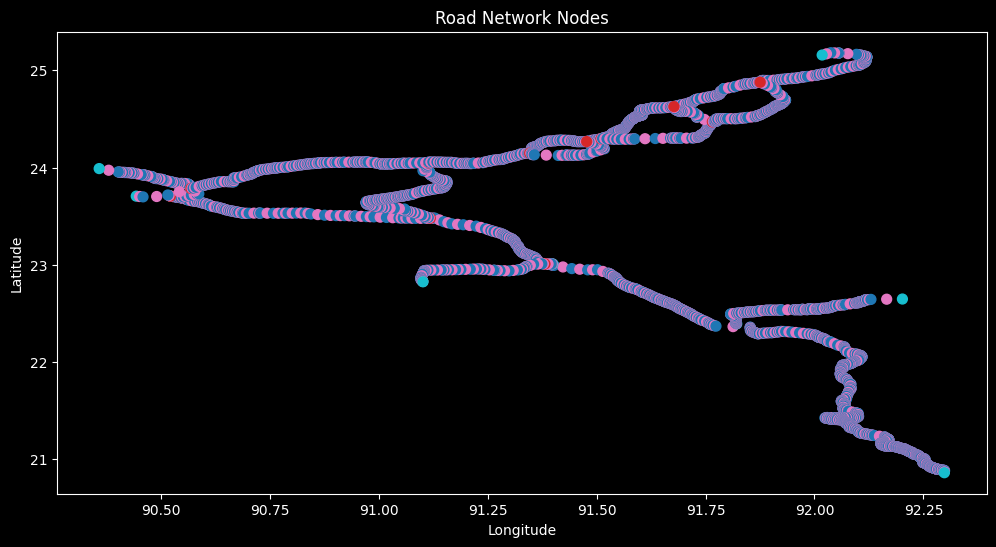

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# kleur automatisch per model_type
colors = final_df_with_links['model_type'].astype('category').cat.codes

plt.scatter(
    final_df_with_links['lon'],
    final_df_with_links['lat'],
    c=colors,
    cmap='tab10',   # mooie colormap
    s=50
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Road Network Nodes')

plt.show()

In [28]:
final_df_with_links.to_csv('../data/data_intersectionsN1N2.csv', na_rep="None")